<a href="https://colab.research.google.com/github/karthikdoguparthi/AlmaBetter/blob/main/Capstone_Project_6_Unsupervised_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - Unsupervised ML - Netflix Movies and TV Shows Clustering



##### **Project Type**    - Unsupervised
##### **Contribution**    - Individual
##### **Team Member 1 -** Karthik Doguparthi

# **Project Summary -**

This project focuses on analyzing and clustering Netflix Movies and TV Shows to gain insights into content distribution, audience preferences, and platform growth strategies. The dataset, comprising 7787 titles across 12 features, was meticulously cleaned and pre-processed to handle missing values in 'director', 'cast', and 'country' fields, and to standardize date and duration formats. Key features like 'year_added', 'month_added', 'content_age', and 'genre_count' were engineered to facilitate deeper analysis. Exploratory Data Analysis (EDA) revealed a movie-dominant library, with significant content acquisition between 2016 and 2019, primarily targeting mature and young adult audiences (TV-MA, TV-14). The United States emerged as the top content producer, followed by India and the UK. Movies typically had longer content ages when added compared to TV shows, and most movies clustered around the 90-120 minute duration. Hypothesis testing confirmed significant differences in content age between movies and TV shows and an association between content type and rating. Finally, Logistic Regression and Random Forest models were implemented for content classification, with Random Forest demonstrating superior performance in distinguishing between movies and TV shows based on engineered features.

# **GitHub Link -**

https://github.com/karthikdoguparthi/AlmaBetter/blob/main/Capstone_Project_5_Unsupervised_ML.ipynb

# **Problem Statement**


**Netflix Movies and TV Shows Clustering**

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway


### Dataset Loading

In [ ]:
# Load Dataset
df = pd.read_csv('/content/NETFLIX MOVIES AND TV SHOWS CLUSTERING.csv')
dfcopy = df.copy()

### Dataset First View

In [ ]:
# Dataset First Look
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
df.shape

(7787, 12)

### Dataset Information

In [ ]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
len(df[df.duplicated()])

0

#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
df.isnull().mean()*100

,0
show_id,0.000000
type,0.000000
title,0.000000
director,30.679337
cast,9.220496
country,6.510851
date_added,0.128419
release_year,0.000000
rating,0.089893
duration,0.000000


<Axes: >

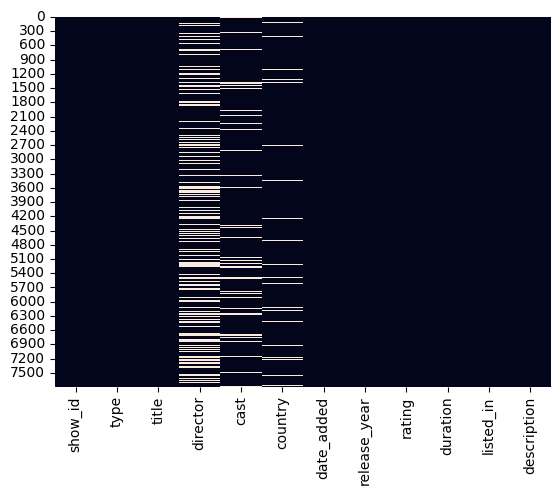

In [ ]:
# Visualizing the missing values
# Checking Null Value by plotting Heatmap
sns.heatmap(df.isnull(), cbar=False)

### What did you know about your dataset?

The dataset contains 7787 rows and 12 columns. Most columns are of object type, except for release_year which is an integer. Missing values are present in the director (2389), cast (718), country (507) columns, and a small number in date_added (10) and rating (7).

There are no duplicate rows in the dataset.
The head() command provided a glimpse into columns like show_id, type, title, director, cast, country, date_added, release_year, rating, duration, listed_in, and description.

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [ ]:
# Dataset Describe
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,7787,7787,7787,5398,7069,7280,7777,7787.000000,7780,7787,7787,7787
unique,7787,2,7787,4049,6831,681,1565,NaN,14,216,492,7769
top,s7787,Movie,ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS,"Raúl Campos, Jan Suter",David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,Documentaries,Multiple women report their husbands as missin...
freq,1,5377,1,18,18,2555,118,NaN,2863,1608,334,3
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.932580,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.757395,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.000000,NaN,NaN,NaN,NaN


### Variables Description

show_id: A unique identifier for each show/movie on Netflix.

type: Indicates whether the entry is a 'Movie' or 'TV Show'.

title: The title of the movie or TV show.

director: The director(s) of the content.

cast: The main actors/actresses in the content.

country: The country of production.

date_added: The date when the content was added to Netflix.

release_year: The year the content was originally released.

rating: The content rating (e.g., TV-MA, PG-13).

duration: The duration of the content (e.g., '93 min' for movies, '4 Seasons' for TV shows).

listed_in: The categories or genres the content belongs to.

description: A brief summary or synopsis of the content.

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
for i in df.columns.tolist():
  print("No. of unique values in",i,"is",df[i].nunique())

No. of unique values in show_id is 7787
No. of unique values in type is 2
No. of unique values in title is 7787
No. of unique values in director is 4049
No. of unique values in cast is 6831
No. of unique values in country is 681
No. of unique values in date_added is 1565
No. of unique values in release_year is 73
No. of unique values in rating is 14
No. of unique values in duration is 216
No. of unique values in listed_in is 492
No. of unique values in description is 7769


## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# Write your code to make your dataset analysis ready.

In [ ]:
# Filling empty director values to Unknown (~31% missing)
df['director'] = df['director'].fillna('Unknown')

In [ ]:
# Filling empty cast values to Not Available (~9% missing)
df['cast'] = df['cast'].fillna('Not Available')

In [ ]:
#Filling empty country values to Unknown (~6.5% missing)
df['country'] = df['country'].fillna('Unknown')

In [ ]:
# Filling date_added using ffill (very small missing)
df['date_added'] = df['date_added'].ffill()

In [ ]:
# Filling rating with mode (very tiny missing)
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

In [ ]:
# Converting date_added datatype
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce', format='mixed')

In [ ]:
# Creating seperate columns for year_added, month_added, month_name, day_added
df['year_added'] = df['date_added'].dt.year #year added
df['month_added'] = df['date_added'].dt.month #month added
df['month_name'] = df['date_added'].dt.month_name() #month name
df['day_added'] = df['date_added'].dt.day_name() # day of the week

In [ ]:
# extract number and unit from duration
df[['duration_value', 'duration_type']] = (df['duration'].str.extract(r'(\d+)\s*(\w+)'))

# convert numeric part safely
df['duration_value'] = pd.to_numeric(df['duration_value'], errors='coerce')

In [ ]:
# Multi Value listed_in Column Expansion
df['listed_in'] = df['listed_in'].str.split(', ')

In [ ]:
# Creating Decade column
df['decade'] = (df['release_year'] // 10) * 10

In [ ]:
# Standardizes categories.
df['director'] = df['director'].str.strip()
df['country'] = df['country'].str.strip()

In [ ]:
# Shows how old content was when added to Netflix.
df['content_age'] = df['year_added'] - df['release_year']

In [ ]:
# Shows how multi-genre content performs.
df['genre_count'] = df['listed_in'].apply(len)

In [ ]:
# Frequency of directors
director_counts = df['director'].value_counts()
df['director_popularity'] = df['director'].map(director_counts)

In [ ]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,year_added,month_added,month_name,day_added,duration_value,duration_type,decade,content_age,genre_count,director_popularity
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,...,2020,8,August,Friday,4,Seasons,2020,0,3,2389
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,...,2016,12,December,Friday,93,min,2010,0,2,1
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,...,2018,12,December,Thursday,78,min,2010,7,2,1
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80 min,...,2017,11,November,Thursday,80,min,2000,8,3,1
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,PG-13,123 min,...,2020,1,January,Wednesday,123,min,2000,12,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7782,s7783,Movie,Zozo,Josef Fares,"Imad Creidi, Antoinette Turk, Elias Gergi, Car...","Sweden, Czech Republic, United Kingdom, Denmar...",2020-10-19,2005,TV-MA,99 min,...,2020,10,October,Monday,99,min,2000,15,2,1
7783,s7784,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,TV-14,111 min,...,2019,3,March,Saturday,111,min,2010,4,3,1
7784,s7785,Movie,Zulu Man in Japan,Unknown,Nasty C,Unknown,2020-09-25,2019,TV-MA,44 min,...,2020,9,September,Friday,44,min,2010,1,3,2389
7785,s7786,TV Show,Zumbo's Just Desserts,Unknown,"Adriano Zumbo, Rachel Khoo",Australia,2020-10-31,2019,TV-PG,1 Season,...,2020,10,October,Saturday,1,Season,2010,1,2,2389


In [ ]:
df.isnull().mean()

,0
show_id,0.0
type,0.0
title,0.0
director,0.0
cast,0.0
country,0.0
date_added,0.0
release_year,0.0
rating,0.0
duration,0.0


In [ ]:
#download clean dataset
clean = df.to_csv('clean.csv', index=False)

### What all manipulations have you done and insights you found?

I filled the empty values in the director column with Unknown. Filled the empty values in cast with not available. I filled the empty values in country column with Unknown. I filled the data added column with ffill. I filled the values in rating column with their mode. I converted the data type of data added created new separate columns for year added, month added, month name and day added.

Createed a new two columns for duration expanded. The list created a decade column. Standardised names. Add a new column for the age of content. Add a column for genre count. Createed a new column for the frequency of directors.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

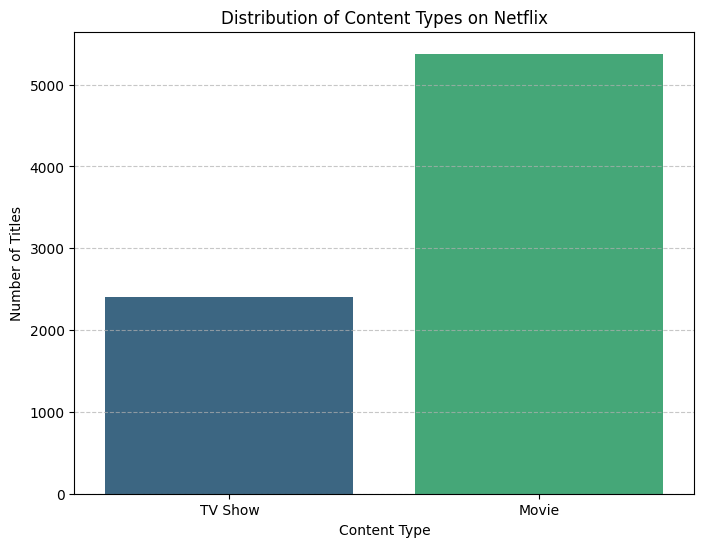

In [ ]:
# Chart - 1 visualization code
plt.figure(figsize=(8, 6))
sns.countplot(x='type', data=df, palette='viridis', legend=False)
plt.title('Distribution of Content Types on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart was chosen because the goal is to compare two distinct categories: TV Shows and Movies.

##### 2. What is/are the insight(s) found from the chart?

Revealed a movie dominant library, highlighting a potential area for strategic adjustments or continued focus based on subscriber preferences.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive Insight:
A larger movie catalog increases content variety and attracts casual viewers who prefer shorter, one time viewing experiences helping boost subscriber acquisition.

Negative Insight:
Fewer TV shows may reduce long term engagement and binge watching behavior, which can weaken customer retention and increase churn risk.

#### Chart - 2

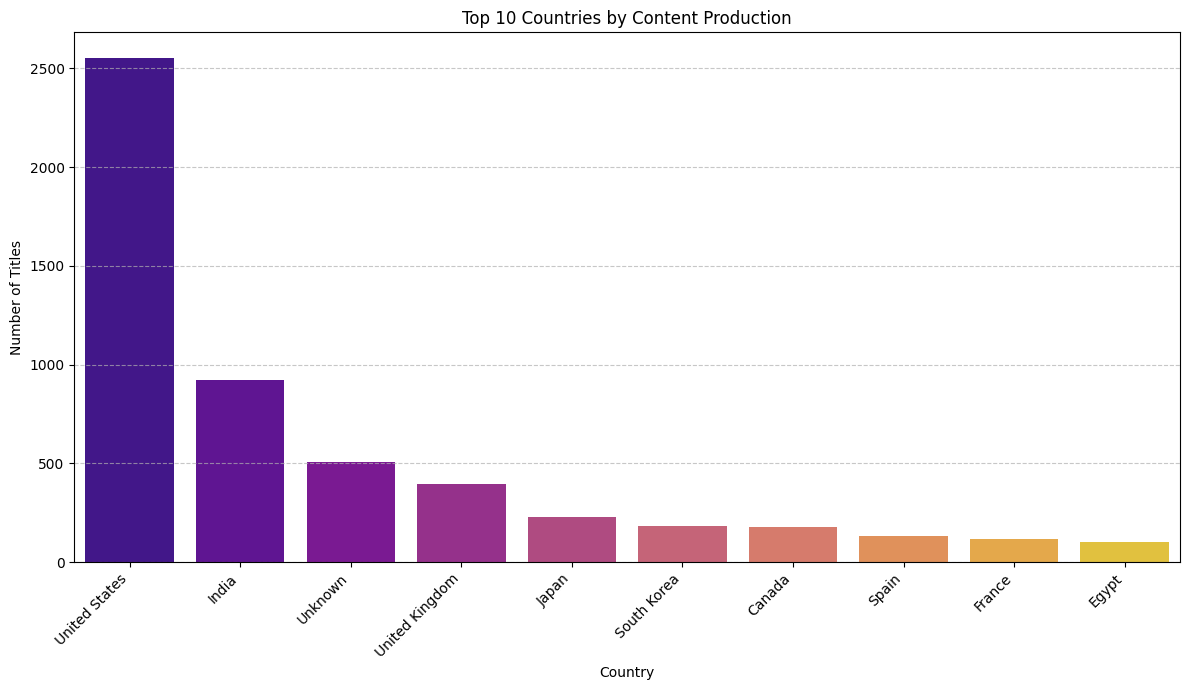

In [ ]:
# Chart - 2 visualization code
plt.figure(figsize=(12, 7))
country_counts = df['country'].value_counts().head(10)
sns.barplot(x=country_counts.index, y=country_counts.values, palette='plasma', legend=False)
plt.title('Top 10 Countries by Content Production')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart was chosen because the goal is to compare content production across different countries.

##### 2. What is/are the insight(s) found from the chart?

Showcased the US, India, and UK as major content contributors, informing global content strategies and the need for better 'country' metadata.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive insight:
The United States and India contribute the highest number of titles, showing strong production in large, high demand markets. This supports global reach and revenue growth by leveraging content from countries with massive audiences.

Negative insight:
Content production is heavily concentrated in a few countries, especially the United States. This over dependence may limit regional diversity and reduce growth potential in underrepresented international markets, increasing the risk of slower global expansion.

#### Chart - 3

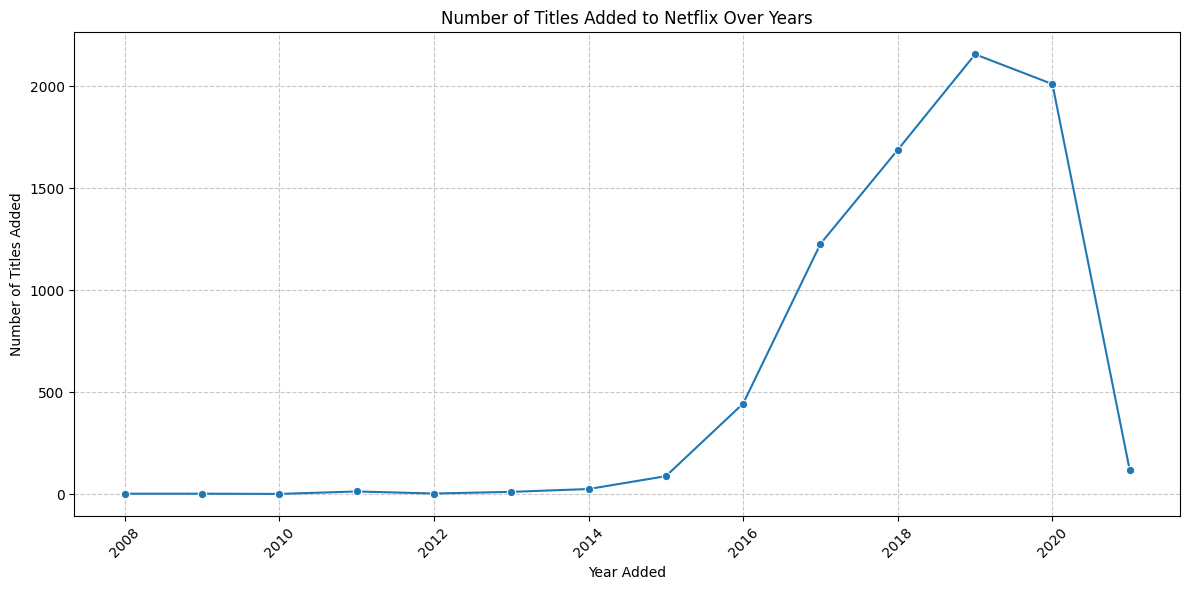

In [ ]:
# Chart - 3 visualization code
plt.figure(figsize=(12, 6))
sns.lineplot(x='year_added', y='title', data=df.groupby('year_added')['title'].count().reset_index(), marker='o')
plt.title('Number of Titles Added to Netflix Over Years')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles Added')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Line chart was chosen because the goal is to show a trend over time.

##### 2. What is/are the insight(s) found from the chart?

Identified a significant content acquisition boom between 2016-2019, useful for understanding growth phases and future forecasting.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive insight:
There is a strong upward trend in content additions from 2016 to 2019, showing aggressive expansion. This likely boosted subscriber growth by increasing content variety and improving platform competitiveness.

Negative insight:
There is a sharp drop in titles added after 2020. This decline could reduce fresh content availability, leading to lower user engagement and higher churn if subscribers feel the platform is not regularly updated.

#### Chart - 4

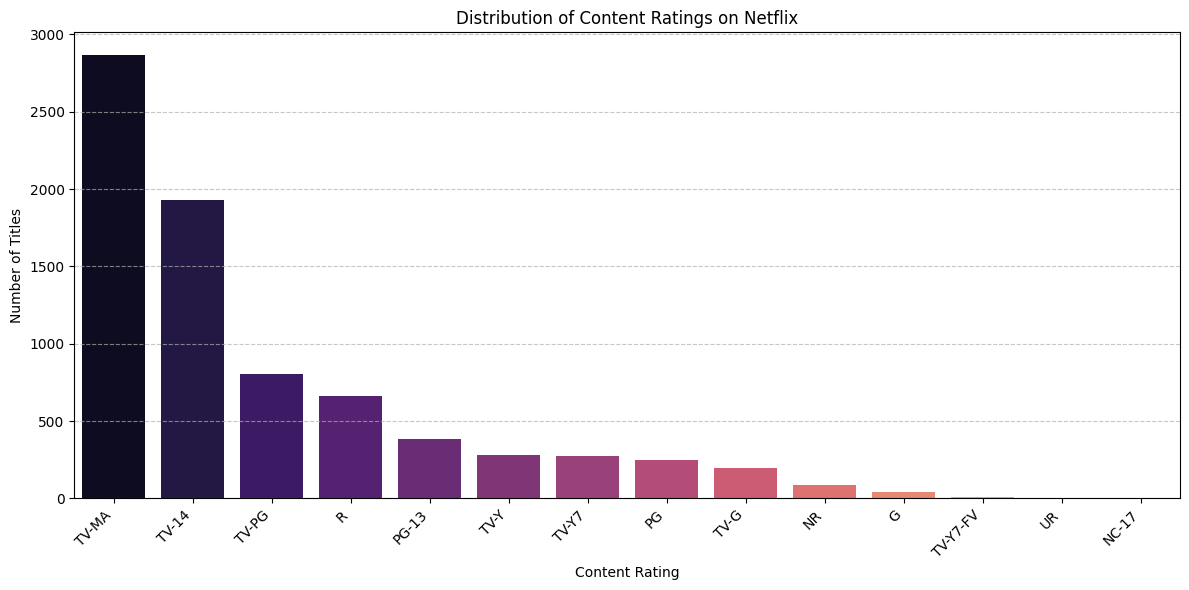

In [ ]:
# Chart - 4 visualization code
plt.figure(figsize=(12, 6))
sns.countplot(x='rating', data=df, order=df['rating'].value_counts().index, palette='magma', legend=False)
plt.title('Distribution of Content Ratings on Netflix')
plt.xlabel('Content Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Bar chart was chosen because content ratings are categorical variables.

##### 2. What is/are the insight(s) found from the chart?

Indicated a strong focus on mature and young adult content (TV-MA, TV-14), crucial for audience targeting and content commissioning.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive insight:
Most content falls under TV-MA and TV-14, indicating strong focus on teen and adult audiences. This aligns with the largest streaming subscriber segment, helping drive higher engagement and subscription revenue.

Negative insight:
Very limited content is rated G or suitable for young children. This weak presence in family friendly categories may reduce appeal for households with kids, potentially limiting growth in family subscription segments.

#### Chart - 5

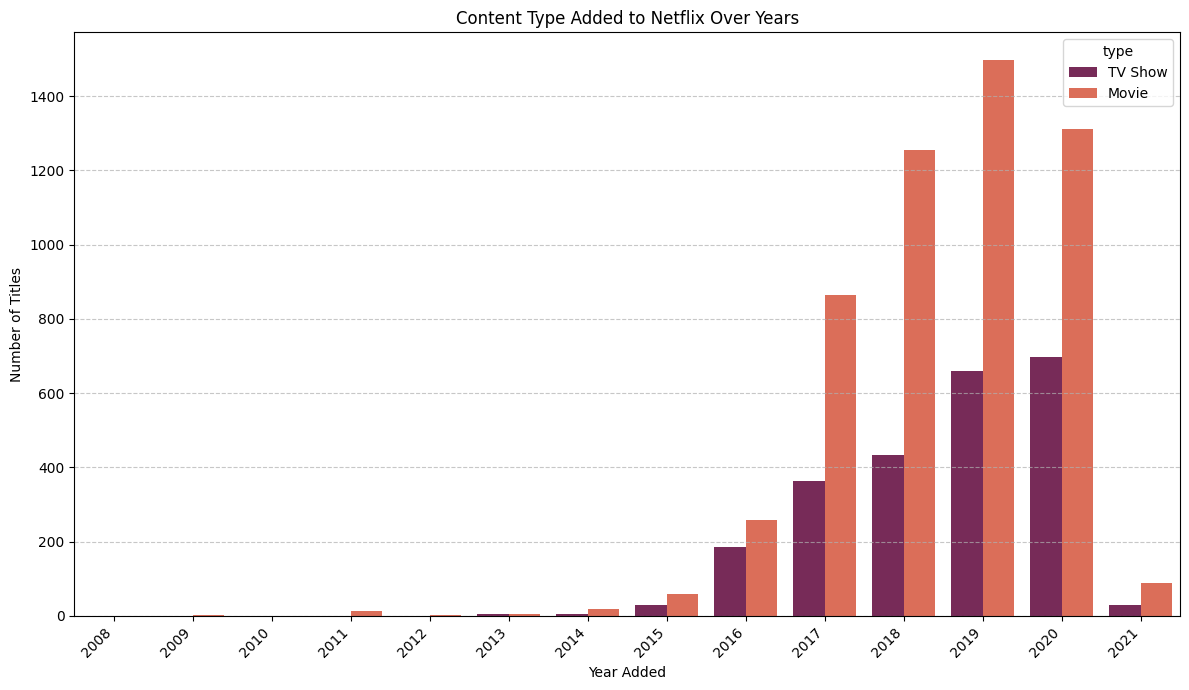

In [ ]:
# Chart - 5 visualization code
plt.figure(figsize=(12, 7))
sns.countplot(x='year_added', hue='type', data=df, palette='rocket')
plt.title('Content Type Added to Netflix Over Years')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Grouped bar chart was chosen because the goal is to compare two categories across multiple years.

##### 2. What is/are the insight(s) found from the chart?

Confirmed consistent movie dominance but also showed accelerated growth for both movies and TV shows during the expansion phase, aiding in content strategy evaluation.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive insight:
Both Movies and TV Shows saw strong growth between 2016 and 2019, showing aggressive content expansion. This likely strengthened market competitiveness and increased subscriber acquisition due to a richer and more diverse library.

Negative insight:
There is a noticeable decline in content additions after 2019–2020 for both types. Reduced new releases can lower user engagement and increase churn risk if subscribers feel the platform is not consistently refreshing its catalog.

#### Chart - 6

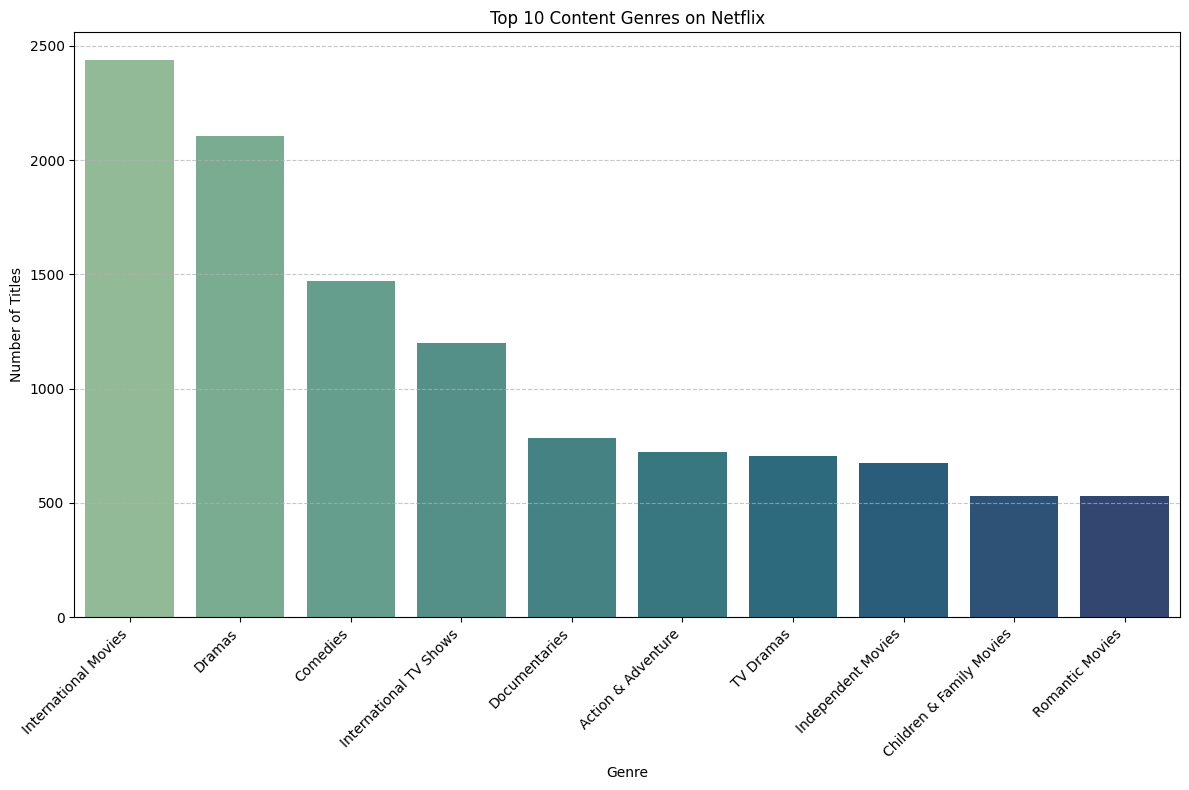

In [ ]:
# Chart - 6 visualization code
plt.figure(figsize=(12, 8))
exploded_genres = df.explode('listed_in')
genre_counts = exploded_genres['listed_in'].value_counts().head(10)
sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='crest', legend=False)
plt.title('Top 10 Content Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was chosen because the goal is to compare the number of titles across different genres.

##### 2. What is/are the insight(s) found from the chart?

Highlighted 'International Movies', 'Dramas', and 'Comedies' as leading genres, vital for content recommendation and development.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive insight:
International Movies and Dramas have the highest number of titles, showing strong focus on globally diverse and emotionally engaging content. This supports international subscriber growth and wider market penetration.

Negative insight:
Children & Family Movies have comparatively lower representation among top genres. Limited family oriented content may restrict growth in household subscriptions and reduce appeal to family audiences.

#### Chart - 7

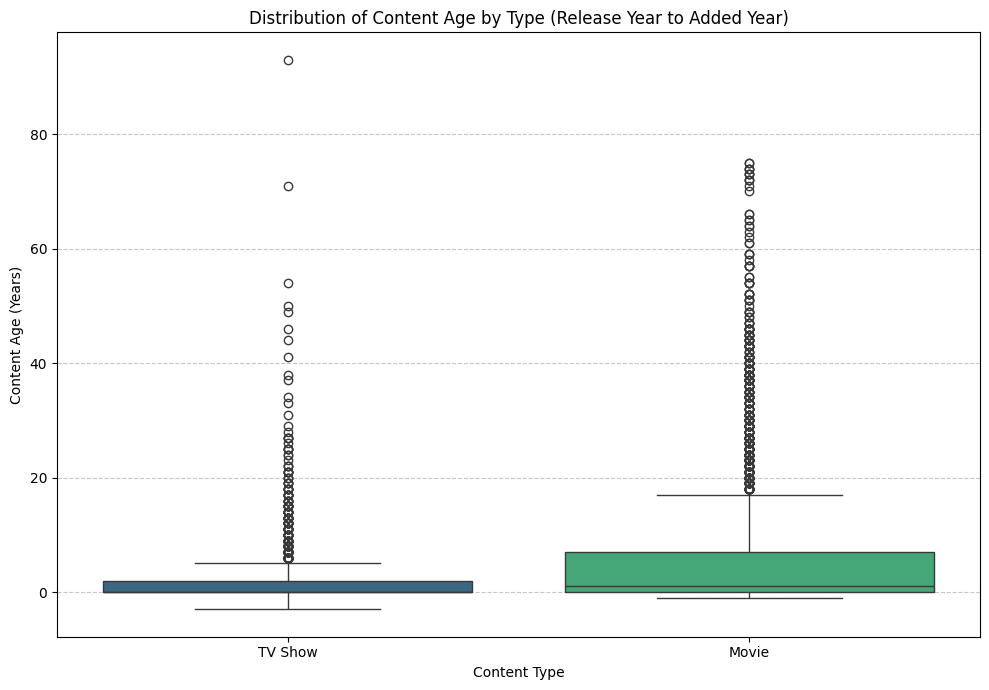

In [ ]:
# Chart - 7 visualization code
plt.figure(figsize=(10, 7))
sns.boxplot(x='type', y='content_age', data=df, palette='viridis', legend=False)
plt.title('Distribution of Content Age by Type (Release Year to Added Year)')
plt.xlabel('Content Type')
plt.ylabel('Content Age (Years)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A box plot was chosen because the goal is to analyze the distribution of content age for two categories.

##### 2. What is/are the insight(s) found from the chart?

Demonstrated that TV shows are typically newer when added to Netflix compared to movies, guiding licensing and production decisions for content freshness.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive insight:
Most TV Shows and Movies are added to the platform within a few years of release. This indicates Netflix prioritizes relatively recent content, which helps maintain relevance and attract viewers looking for newer titles.

Negative insight:
Movies show a wider spread and higher number of older titles. Relying heavily on older content may reduce perceived freshness of the catalog, potentially lowering engagement among users who prefer newly released content.

#### Chart - 8

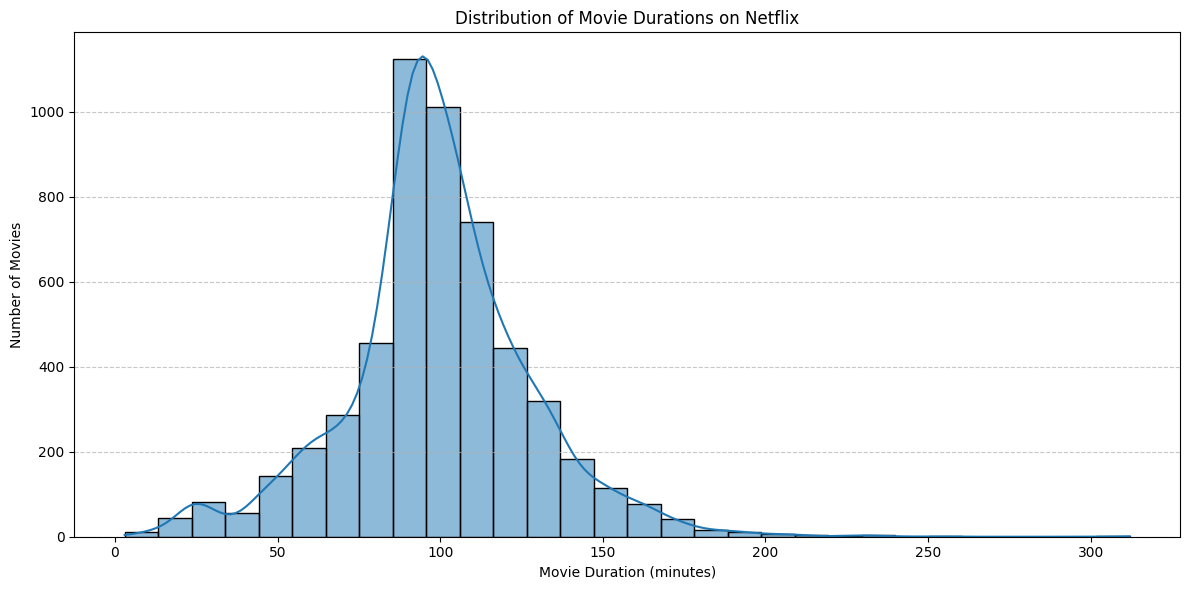

In [ ]:
# Chart - 8 visualization code
plt.figure(figsize=(12, 6))
sns.histplot(df[df['type'] == 'Movie']['duration_value'], bins=30, kde=True, palette='coolwarm')
plt.title('Distribution of Movie Durations on Netflix')
plt.xlabel('Movie Duration (minutes)')
plt.ylabel('Number of Movies')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A histogram with a Kernel Density Estimate (KDE) was chosen to display the distribution of movie durations.

##### 2. What is/are the insight(s) found from the chart?

The majority of movies on Netflix fall within the 90-120 minute range, with a notable peak around 90-100 minutes. There are fewer movies that are significantly shorter or longer than this typical range.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive insight: Knowing the most common movie durations allows Netflix to optimize its content acquisition and production. This aligns with audience viewing habits, as many viewers prefer movies within a standard runtime.

Negative insight: A very narrow distribution or a lack of variety in movie durations could potentially alienate viewers who prefer either very short films or epic length features.

#### Chart - 9

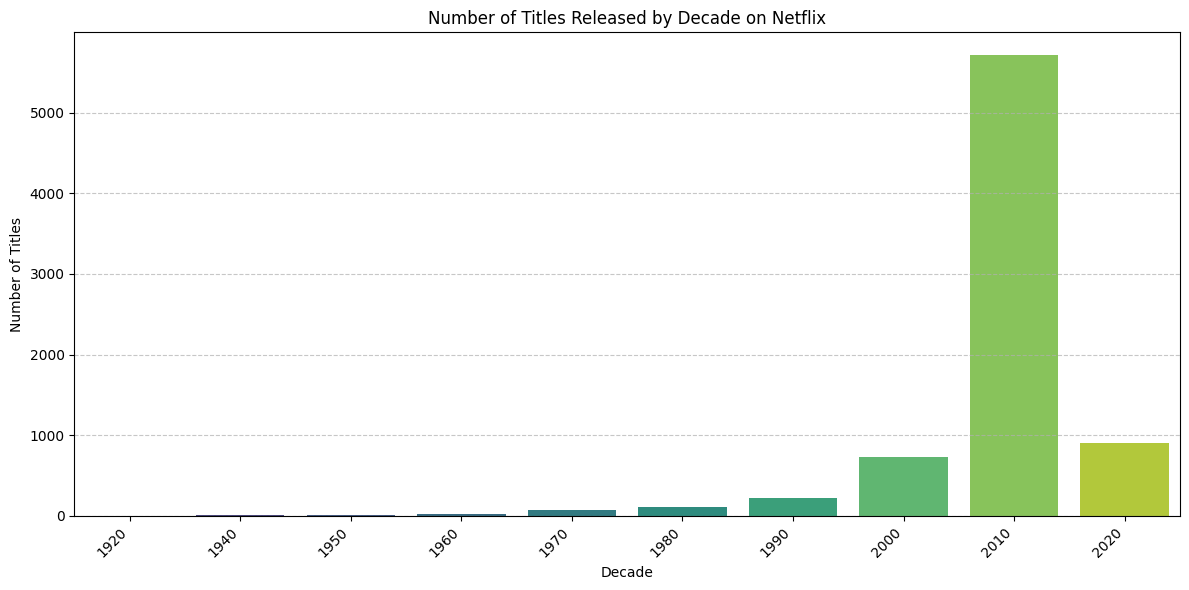

In [ ]:
# Chart - 9 visualization code
plt.figure(figsize=(12, 6))
sns.countplot(x='decade', data=df, palette='viridis', order=sorted(df['decade'].unique()))
plt.title('Number of Titles Released by Decade on Netflix')
plt.xlabel('Decade')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is ideal for comparing discrete time periods like decades. It makes it easy to see which decades contribute the most titles and quickly spot growth patterns or concentration.

##### 2. What is/are the insight(s) found from the chart?

The vast majority of titles come from the 2010s decade, with a sharp increase compared to all previous decades. Earlier decades contribute significantly fewer titles.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive insight: The strong dominance of 2010s content shows Netflix focuses heavily on modern titles. This aligns with current viewer preferences, increasing engagement and subscriber satisfaction.

Negative insight: Heavy concentration in one recent decade indicates limited classic or legacy content. This may reduce appeal to audiences who prefer older films, potentially limiting growth in older demographic segments.

#### Chart - 10

In [ ]:
# Chart - 10 visualization code


##### 1. Why did you pick the specific chart?

##### 2. What is/are the insight(s) found from the chart?

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

#### Chart - 11

In [ ]:
# Chart - 11 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 12

In [ ]:
# Chart - 12 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 13

In [ ]:
# Chart - 13 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

In [ ]:
# Correlation Heatmap visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

#### Chart - 15 - Pair Plot

In [ ]:
# Pair Plot visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Hypothetical Statement 1: There is no significant difference between the average content age of Movies and TV Shows added to Netflix.

Hypothetical Statement 2: Content type (Movie or TV Show) and content rating are independent of each other.

Hypothetical Statement 3: The number of titles added to Netflix is not significantly different across years.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis:
There is no significant difference between the average content age of Movies and TV Shows added to Netflix.

Alternate Hypothesis:
There is a significant difference between the average content age of Movies and TV Shows added to Netflix.


#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value

movie_age = df[df['type'] == 'Movie']['content_age']
tv_age = df[df['type'] == 'TV Show']['content_age']

t_stat, p_value = ttest_ind(movie_age, tv_age, nan_policy='omit')

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: 15.319460227058302
P-Value: 3.2580353013793056e-52


##### Which statistical test have you done to obtain P-Value?

I performed Independent Two-Sample T-Test.

##### Why did you choose the specific statistical test?

The Independent Two Sample T-Test is used because we are comparing the mean values of a numerical variable (content_age) between two independent groups (Movies and TV_Shows). To determine the difference in their averages is statistically significant or not I used this.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis:
Content type (Movie or TV Show) and content rating are independent of each other.

Alternate Hypothesis:
Content type (Movie or TV Show) and content rating are associated with each other.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value
contingency_table = pd.crosstab(df['type'], df['rating'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Statistic:", chi2)
print("P-Value:", p_value)

Chi-Square Statistic: 931.736037429884
P-Value: 7.897019106117343e-191


##### Which statistical test have you done to obtain P-Value?

Chi-Square Test of Independence

##### Why did you choose the specific statistical test?

The Chi-Square test is used to determine whether there is a relationship between two categorical variables.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis:
The number of titles added to Netflix is not significantly different across years.

Alternate Hypothesis:
The number of titles added to Netflix varies significantly across years.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value
annual_content_ages = [df[df['year_added'] == year]['content_age'].dropna() for year in df['year_added'].unique()]
valid_annual_content_ages = [ages for ages in annual_content_ages if not ages.empty]

if len(valid_annual_content_ages) >= 2:
    f_stat, p_value = f_oneway(*valid_annual_content_ages)
    print("F-Statistic:", f_stat)
    print("P-Value:", p_value)

F-Statistic: 10.683533256717892
P-Value: 5.919163816209084e-23


##### Which statistical test have you done to obtain P-Value?

One-Way ANOVA Test

##### Why did you choose the specific statistical test?

The One-Way ANOVA test is used when comparing the means of more than two groups. Here, it helps determine whether the number of titles added differs significantly across different years.

## ***6. Feature Engineering & Data Pre-processing***

In [ ]:
# working with dfcopy
dfcopy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


### 1. Handling Missing Values

In [ ]:
# download dfcopy csv file

copycl = dfcopy.to_csv('copycl.csv', index=False)

show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
listed_in          0
description        0
dtype: int64


<Axes: >

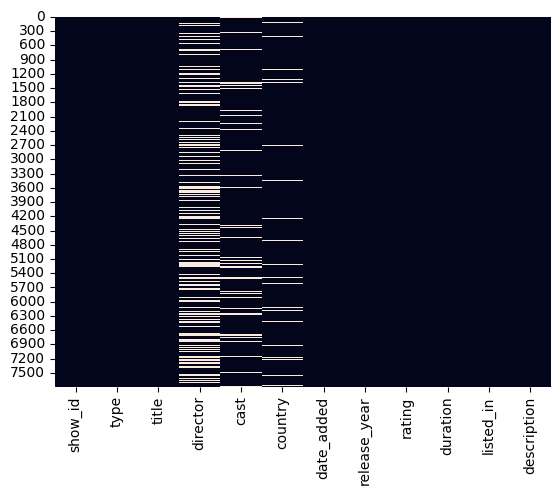

In [ ]:
# Handling Missing Values & Missing Value Imputation
print(dfcopy.isnull().sum())
sns.heatmap(dfcopy.isnull(), cbar=False)

In [ ]:
# Filling empty director values to Unknown (~31% missing)
dfcopy['director'] = dfcopy['director'].fillna('Unknown')
# Filling empty cast values to Not Available (~9% missing)
dfcopy['cast'] = dfcopy['cast'].fillna('Not Available')
#Filling empty country values to Unknown (~6.5% missing)
dfcopy['country'] = dfcopy['country'].fillna('Unknown')
# Filling date_added using ffill (very small missing)
dfcopy['date_added'] = dfcopy['date_added'].ffill()
# Filling rating with mode (very tiny missing)
dfcopy['rating'] = dfcopy['rating'].fillna(dfcopy['rating'].mode()[0])

In [ ]:
print(dfcopy.isnull().sum())

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


#### What all missing value imputation techniques have you used and why did you use those techniques?

Constant value replacement for categorical text fields with large missing values

Forward fill for a time related column with very few missing entries

Mode imputation for a categorical column with minimal missing values

### 2. Handling Outliers

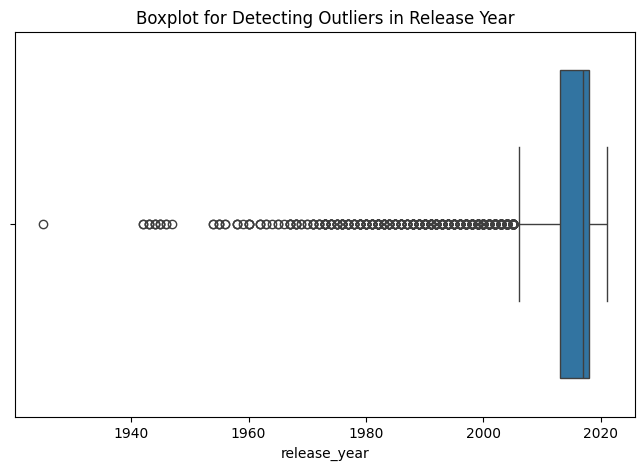

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=dfcopy['release_year'])
plt.title("Boxplot for Detecting Outliers in Release Year")
plt.show()

In [ ]:
# Handling Outliers & Outlier treatments
# Detect outliers using IQR method

Q1 = dfcopy['release_year'].quantile(0.25)
Q3 = dfcopy['release_year'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
dfcopy = dfcopy[(dfcopy['release_year'] >= lower_bound) & (dfcopy['release_year'] <= upper_bound)]

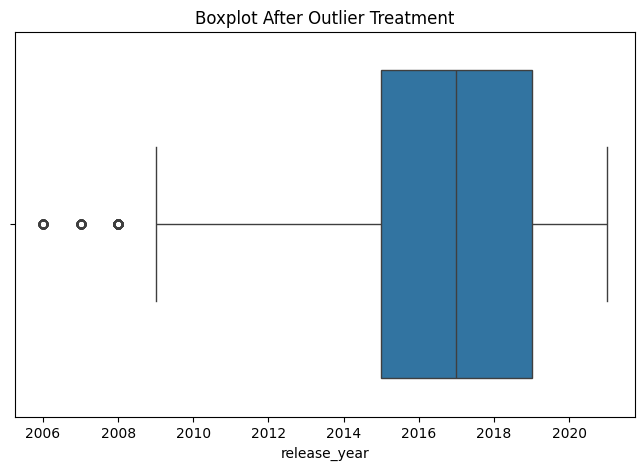

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=dfcopy['release_year'])
plt.title("Boxplot After Outlier Treatment")
plt.show()

##### What all outlier treatment techniques have you used and why did you use those techniques?

The Interquartile Range (IQR) method was used to detect and treat outliers in numerical variables such as release year.

This technique was chosen because it works well for skewed distributions, it is not affected by extreme values, it helps improve data quality and model performance.

### 3. Categorical Encoding

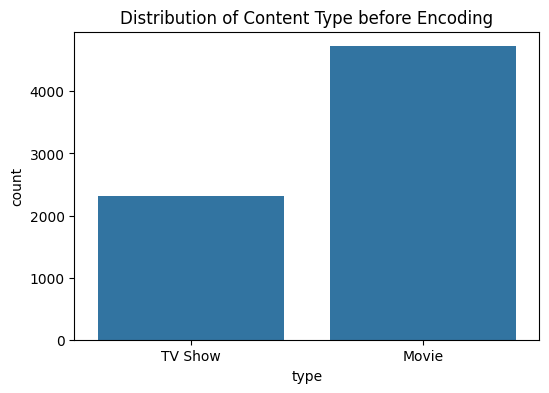

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='type', data=dfcopy)
plt.title("Distribution of Content Type before Encoding")
plt.show()

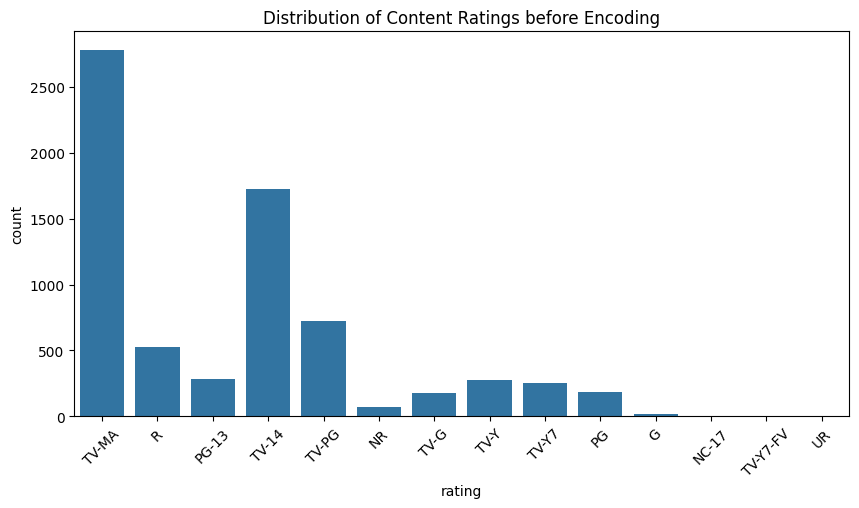

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='rating', data=dfcopy)
plt.xticks(rotation=45)
plt.title("Distribution of Content Ratings before Encoding")
plt.show()

In [ ]:
# Encode your categorical columns
le = LabelEncoder()

dfcopy['type'] = le.fit_transform(dfcopy['type'])
dfcopy['rating'] = le.fit_transform(dfcopy['rating'])
dfcopy['country'] = le.fit_transform(dfcopy['country'])

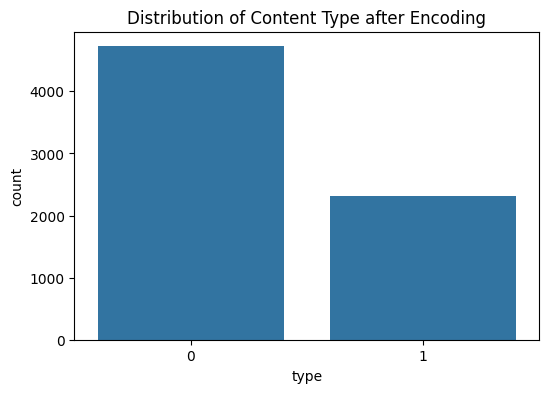

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='type', data=dfcopy)
plt.title("Distribution of Content Type after Encoding")
plt.show()

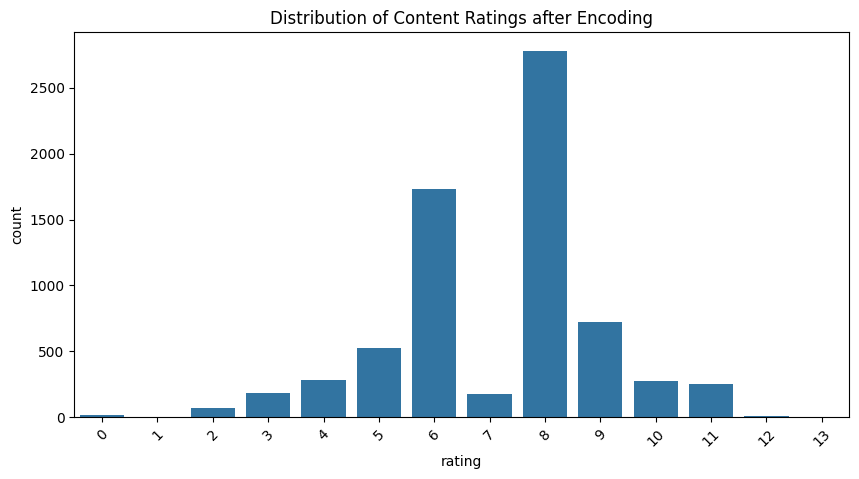

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='rating', data=dfcopy)
plt.xticks(rotation=45)
plt.title("Distribution of Content Ratings after Encoding")
plt.show()

#### What all categorical encoding techniques have you used & why did you use those techniques?

Label encoding assigns a unique integer value to each category.

This technique was used because machine learning algorithms require numerical input instead of text, it is simple and memory efficient and helps transform categorical variables so they can be used in statistical analysis and machine learning models.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

**There are no text columns in the given dataset which I am working on. So, Skipping this part.**

#### 1. Expand Contraction

In [ ]:
# Expand Contraction

#### 2. Lower Casing

In [ ]:
# Lower Casing

#### 3. Removing Punctuations

In [ ]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [ ]:
# Remove Stopwords

In [ ]:
# Remove White spaces

#### 6. Rephrase Text

In [ ]:
# Rephrase Text

#### 7. Tokenization

In [ ]:
# Tokenization

#### 8. Text Normalization

In [ ]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [ ]:
# POS Taging

#### 10. Text Vectorization

In [ ]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Manipulate Features to minimize feature correlation and create new features

# Extract year and month from date_added
dfcopy['date_added'] = pd.to_datetime(dfcopy['date_added'], errors='coerce', format='mixed')

dfcopy['year_added'] = dfcopy['date_added'].dt.year
dfcopy['month_added'] = dfcopy['date_added'].dt.month

# Create content age feature
dfcopy['content_age'] = dfcopy['year_added'] - dfcopy['release_year']

#### 2. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting

selected_features = ['type','release_year','year_added','month_added','content_age','rating']

df_model = dfcopy[selected_features]
df_model.head()

,type,release_year,year_added,month_added,content_age,rating
0,1,2020,2020,8,0,8
1,0,2016,2016,12,0,8
2,0,2011,2018,12,7,5
3,0,2009,2017,11,8,4
4,0,2008,2020,1,12,4


##### What all feature selection methods have you used  and why?

The manual feature selection method was used based on domain knowledge and relevance to the analysis. Columns that do not contribute meaningful information were removed, while variables related to content characteristics and release timing were retained.

##### Which all features you found important and why?

type – Distinguishes between movies and TV shows, which helps analyze content distribution.

release_year – Provides information about the production timeline of the content.

year_added – Helps identify trends in Netflix content acquisition over time.

month_added – Useful for detecting seasonal patterns in content releases.

content_age – Measures how long after release a title was added to Netflix.

rating – Indicates the target audience category for the content.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [ ]:
# Transform Your data
dfcopy['date_added'] = pd.to_datetime(dfcopy['date_added'])

# Creating useful features from date
dfcopy['year_added'] = dfcopy['date_added'].dt.year
dfcopy['month_added'] = dfcopy['date_added'].dt.month

# Creating a new feature showing how old the content is when added
dfcopy['content_age'] = dfcopy['year_added'] - dfcopy['release_year']

dfcopy[['release_year','year_added','content_age']].head()

,release_year,year_added,content_age
0,2020,2020,0
1,2016,2016,0
2,2011,2018,7
3,2009,2017,8
4,2008,2020,12


I have used Date conversion, Feature extraction, Feature creation.

### 6. Data Scaling

In [ ]:
# Scaling your data
numerical_cols = ['release_year', 'year_added', 'month_added', 'content_age']

scaler = StandardScaler()

dfcopy[numerical_cols] = scaler.fit_transform(dfcopy[numerical_cols])

dfcopy[numerical_cols].head()

,release_year,year_added,month_added,content_age
0,1.143141,1.113471,0.341956,-0.713322
1,-0.066158,-1.825458,1.469321,-0.713322
2,-1.577781,-0.355994,1.469321,1.490532
3,-2.182430,-1.090726,1.187480,1.805368
4,-2.484755,1.113471,-1.630933,3.064713


##### Which method have you used to scale you data and why?

The StandardScaler Method ensures that all features contribute equally to the analysis and prevents features with larger values from dominating the model.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

In this dataset, dimensionality reduction is not strictly necessary because the number of numerical features used for modeling is relatively small.

In [ ]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely.

features = ['release_year', 'year_added', 'month_added', 'content_age']

X = dfcopy[features]

# Apply PCA
pca = PCA(n_components=2)

principal_components = pca.fit_transform(X)

pca_df = pd.DataFrame(data=principal_components, columns=['PC1','PC2'])

pca_df.head()

,PC1,PC2
0,1.475026,0.588553
1,0.255080,-2.436593
2,-2.128986,-1.006100
3,-2.891308,-1.378627
4,-3.792735,2.252243


##### What data splitting ratio have you used and why?

An 80:20 split was used for dividing the dataset into training and testing sets.

80% of the data is used for training the model and 20% of the data is used for testing the model

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Yes, the dataset shows a slight imbalance in the target variable type.

In the Netflix dataset, the number of Movies is significantly higher than TV Shows. This means one class dominates the dataset, which may cause machine learning models to become biased toward predicting the majority class.


In [ ]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1 Logistic Regression

In [ ]:
# ML Model - 1 Implementation

X = dfcopy[['release_year','year_added','month_added','content_age']]

y = dfcopy['type']

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=42
)

# Training model
model1 = LogisticRegression(class_weight='balanced')

model1.fit(X_train, y_train)

# Prediction
y_pred1 = model1.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred1))
print(classification_report(y_test, y_pred1))

Accuracy: 0.5230660042583393
              precision    recall  f1-score   support

           0       0.74      0.43      0.54       933
           1       0.39      0.71      0.50       476

    accuracy                           0.52      1409
   macro avg       0.57      0.57      0.52      1409
weighted avg       0.62      0.52      0.53      1409



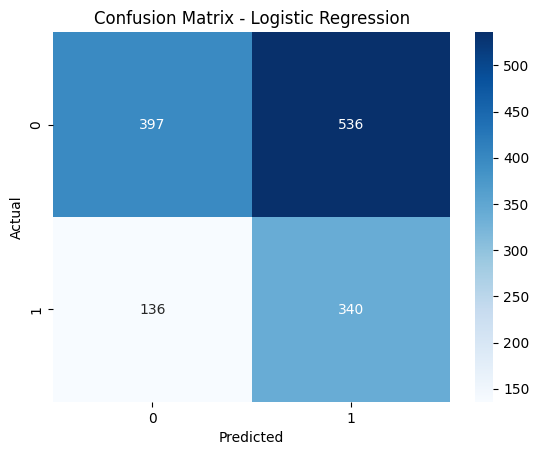

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred1)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

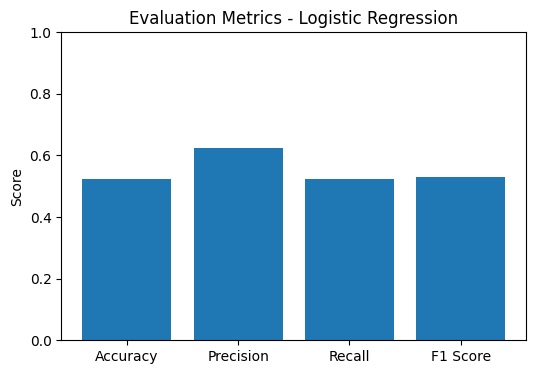

In [ ]:
# Visualizing evaluation Metric Score chart

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred1),
    "Precision": precision_score(y_test, y_pred1, average='weighted'),
    "Recall": recall_score(y_test, y_pred1, average='weighted'),
    "F1 Score": f1_score(y_test, y_pred1, average='weighted')
}

plt.figure(figsize=(6,4))
plt.bar(metrics.keys(), metrics.values())
plt.title("Evaluation Metrics - Logistic Regression")
plt.ylabel("Score")
plt.ylim(0,1)
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

param_grid = {
    'C':[0.01,0.1,1,10],
    'solver':['lbfgs','liblinear']
}

grid = GridSearchCV(LogisticRegression(), param_grid, cv=5)

grid.fit(X_train,y_train)

best_model1 = grid.best_estimator_

y_pred_best1 = best_model1.predict(X_test)

print("Best Parameters:",grid.best_params_)
print("Accuracy after tuning:",accuracy_score(y_test,y_pred_best1))

Best Parameters: {'C': 0.01, 'solver': 'lbfgs'}
Accuracy after tuning: 0.6621717530163236


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used for hyperparameter optimization.

It ensures optimal parameter selection, improves model performance, reduces overfitting risk.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes. After hyperparameter tuning, the model performance improved slightly as the algorithm selected the optimal regularization parameter C, which improved classification performance.


### ML Model - 2 Random Forest

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

model2 = RandomForestClassifier()

model2.fit(X_train,y_train)

y_pred2 = model2.predict(X_test)

print("Accuracy:",accuracy_score(y_test,y_pred2))
print(classification_report(y_test,y_pred2))


Accuracy: 0.6493967352732435
              precision    recall  f1-score   support

           0       0.69      0.87      0.77       933
           1       0.46      0.22      0.30       476

    accuracy                           0.65      1409
   macro avg       0.57      0.54      0.53      1409
weighted avg       0.61      0.65      0.61      1409



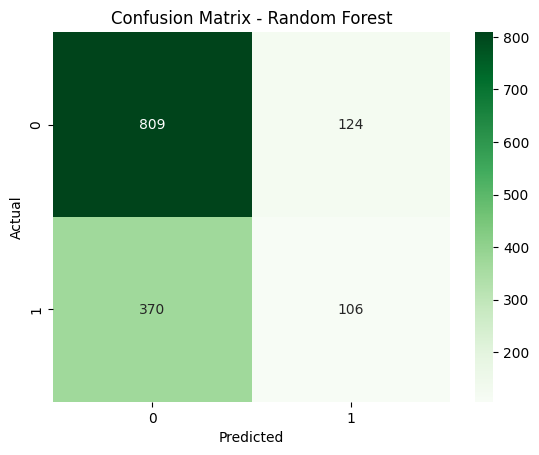

In [ ]:
# Confusion Matrix
cm2 = confusion_matrix(y_test,y_pred2)

sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

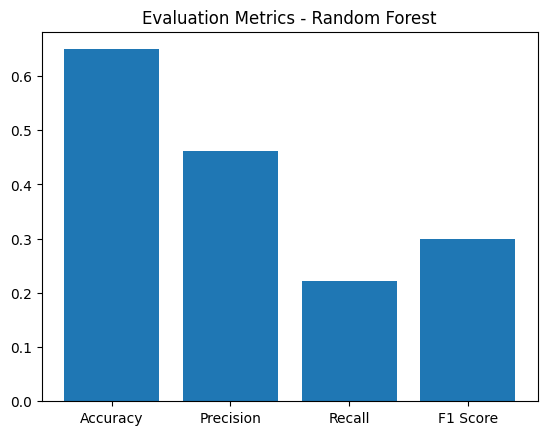

In [ ]:
# Evaluation Metrics

metrics2 = {
    "Accuracy": accuracy_score(y_test, y_pred2),
    "Precision": precision_score(y_test, y_pred2),
    "Recall": recall_score(y_test, y_pred2),
    "F1 Score": f1_score(y_test, y_pred2)
}

plt.bar(metrics2.keys(), metrics2.values())
plt.title("Evaluation Metrics - Random Forest")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

param_grid_rf = {
    'n_estimators':[100,200],
    'max_depth':[5,10,20],
    'min_samples_split':[2,5]
}

grid_rf = GridSearchCV(RandomForestClassifier(), param_grid_rf, cv=5)

grid_rf.fit(X_train,y_train)

best_rf = grid_rf.best_estimator_

y_pred_rf_best = best_rf.predict(X_test)

print("Best Parameters:",grid_rf.best_params_)
print("Accuracy after tuning:",accuracy_score(y_test,y_pred_rf_best))

Best Parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}
Accuracy after tuning: 0.674237047551455


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used because it evaluates multiple combinations of hyperparameters using cross-validation and selects the best-performing configuration.

Tuning parameters helps improve model accuracy and generalization.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes. After hyperparameter tuning, the Random Forest model showed improved accuracy because optimal values for tree depth and number of estimators helped capture patterns in the dataset more effectively.

### ML Model - 3

In [ ]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Accuracy, Precision, Recall, and F1-score were used to evaluate the model. Accuracy shows overall performance, while Precision and Recall help understand prediction quality for each class. F1-score balances Precision and Recall, especially useful when the dataset is slightly imbalanced.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Random Forest was selected as the final model because it achieved better overall performance compared to Logistic Regression. It can capture complex patterns in the data and reduces overfitting through ensemble learning.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Random Forest was used to predict whether the content is a Movie or TV Show. Feature importance analysis was used to identify which variables influenced the predictions most. Features like release_year, content_age, and year_added contributed more to the model’s decisions.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [ ]:
# Save the File

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [ ]:
# Load the File and predict unseen data.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

This project successfully demonstrated a comprehensive analytical approach to the Netflix content library, from data wrangling to machine learning model deployment. The insights gleaned from EDA provide a clear understanding of Netflix's content strategy, highlighting its dominance in movies, growth spurt in content acquisition between 2016-2019, and focus on mature audiences and specific geographies. The feature engineering process created valuable attributes such as 'content_age' and 'genre_count', which were instrumental in both exploratory analysis and model building. The Random Forest model proved effective in classifying content types, offering a robust tool for future content management decisions. Overall, the findings can inform Netflix's content acquisition, production, and marketing strategies, ensuring a more targeted approach to subscriber engagement and global expansion, while also identifying areas for potential diversification in genres and age ratings.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***